In [1]:
!pip install tqdm numpy scipy matplotlib git+https://github.com/das-dias/PyMUST.git scikit-image

  Cloning https://github.com/das-dias/PyMUST.git to /tmp/pip-req-build-xkcswai6
  Running command git clone --filter=blob:none --quiet https://github.com/das-dias/PyMUST.git /tmp/pip-req-build-xkcswai6
  Resolved https://github.com/das-dias/PyMUST.git to commit f23626b373c822c5e9daeb4bac55e4e70a2d45c9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for PyMUST: filename=pymust-0.1.dev97+gf23626b37-py3-none-any.whl size=125332 sha256=3b27344721ceedf26ff316dc210dab334f27f5a34fdac254a188a6dc46655fca
  Stored in directory: /tmp/pip-ephem-wheel-cache-q_40a6am/wheels/6c/f2/8e/621ef6d2cd9acb1eade684d5ac9f0663a821ec03ea35ee9c85
Successfully built PyMUST


# Monte Carlo Simulations - Non-Ideal Charge-Sharing Compressive Multiplexing Architecture

This Jupyter Notebook contains simulation setups for performing an analysis of how the envisaged Charge-Sharing Compressive Multiplexer and its non-idealities at block and circuit level affect  Ultrasound B-mode and Color Doppler imaging quality.

In [2]:
from copy import deepcopy
from scipy.ndimage import shift
from scipy.sparse import lil_matrix, csr_matrix
from scipy.signal import gausspulse


import numpy as np
import scipy.signal as sp
import scipy.fft as spfft
import numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import pymust

from skimage.restoration import denoise_bilateral

Setup Analog Front End Model, to run Monte-Carlo Simulation

In [3]:
## Obtain golden-standard image to enable image quality metric (IQM) comparison with the remainder of the images

def boxcar_averager(data, param, order=2):
    """
    Smoothes an N x K matrix along the N axis (rows)
    independently for each of the K columns.
    """

    from scipy.signal import butter, lfilter, firwin
    from scipy.interpolate import interp1d
    #fmax = self.param.fc * (0.5*self.param.bandwidth/100 + 1.0)
    cutoff = 2*param.fc
    nyquist = 0.5 * param.fs
    Wn = cutoff/nyquist
    h = firwin(order, Wn, window='boxcar')
    return lfilter(h, 1.0, data)

class IdelAFE():
  def __init__(self, param):
    self.param = param

  def __call__(self, RF):
    RF_tgc, _ = pymust.tgc(RF)
    IQ = pymust.rf2iq(RF_tgc/np.max(np.abs(RF_tgc)),self.param.fs,self.param.fc)
    IQ = boxcar_averager(IQ, param)
    return IQ, RF_tgc

In [4]:
RUN_RF_SIMULATIONS = False
ROWS = 40
COLUMNS = 40
KERF = 25e-6

MAX_ANGLE = 15.0 # 10.0
MIN_ANGLE = -15.0 # -10.0
NUM_PLANAR_WAVES = 5
DIVERGENT_ANGLE = 15.0

f0_settings = np.array([2.0, 2.5, 4.0, 6.0])*1e6

In [5]:
if RUN_RF_SIMULATIONS:
  for f0_setting in f0_settings:

    # Setup 2D array parameters:
    param = pymust.utils.Param()
    param.fc = f0_setting
    wavelength = c0 / f0_setting
    pitch = wavelength / 2
    param.kerf = KERF
    param.pitch = pitch
    param.width = pitch - param.kerf
    param.height = ROWS * pitch - param.kerf
    param.Nelements = COLUMNS
    param.bandwidth = 70
    param.radius = np.inf

    param.fs = 4*param.fc
    param.attenuation = 0.5

    # Setup the transmit events
    tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
    width = DIVERGENT_ANGLE/180*np.pi # Diverging wave width with 30 degrees
    txdel = []
    for t in tilt:
        txdel.append(pymust.txdelay(param, t, width))
    txdel_planar = np.array(txdel)
    np.save(dir / f'txdelays_f0_setting_{f0_setting/1e6:.2f}_mhz.npy', txdel_planar)

    # Simulate and setup the raw RF ultrasound data
    RF = [0]*len(txdel_planar)
    for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
      RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
    # Save the raw RF data
    for transmit_event, r in enumerate(RF):
      np.save(dir / f"us_raw_rf_f0_setting_{f0_setting/1e6:.2f}_mhz_tx_event_{transmit_event}.npy", r)

In [6]:
#from typing import NamedTuple
from dataclasses import dataclass, asdict
@dataclass
class AFEConfig:
  snr: float = np.inf # dB
  hd2: float = np.inf # dB
  hd3: float = np.inf # dB
  gain_range: float = 40 # dB
  psrr: float = np.inf # dB
  gain_err: float = 0.0 #dB
  linear_dynamic_range: float = np.inf #dB
  bw: float = 0.49 # bandwidth multiplifer relative to transducer Fs
  # in this design the bandwidth
  #fs: float = 4.0 # sampling frequency multiplifer relative to transducer Fc
  discrete: bool = False
  gain_steps: int = 1000
  sub_array_size: int = 1
  filter_order: int = 2
  jitter_std: float = 0.0 # s
  settling: float = 10 # Ts / boxcar_tap_settling
  max_input_range: float = 1.0 # 0.45 Volt
  supply: float = 1.8 # V

  def __setitem__(self, key, value):
    # Check if the attribute exists to prevent adding random keys
    if hasattr(self, key):
        setattr(self, key, value)
    else:
        raise KeyError(f"'{key}' is not a valid parameter in FilterParams")

  def __getitem__(self, key):
    return getattr(self, key)

  def default(self):
    targets = ['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err']
    return {key:asdict(self)[key] for key in targets}

In [7]:


class AFE():
  def __init__(self, param, afe_cfg: AFEConfig):
    self.param = param
    self.cfg = afe_cfg

  def _add_noise(self, r):
    irn_rms = self.cfg.max_input_range / 10**(self.cfg.snr/20)
    noise = np.random.normal(0, irn_rms/np.sqrt(self.cfg.sub_array_size), r.shape)
    return r + noise

  def _add_psrr_induced_noise(self, r):
    psrr_irn = self.cfg.supply / 10**(self.cfg.psrr / 20)
    psrr_irn = psrr_irn / np.sqrt(self.cfg.sub_array_size)
    noise = np.random.normal(0, psrr_irn, r.shape)
    return r + noise

  def _add_distortion(self, r):
    r2 = np.square(r)
    r3 = np.power(r, 3)
    hd2_amplitude = 10 ** (-self.cfg.hd2 / 20)
    hd3_amplitude = 10 ** (-self.cfg.hd3 / 20)

    return r + hd2_amplitude * r2 + hd3_amplitude * r3

  def _filter(self, r):
    # this function applies the zero-order sample and hold filtering within the system
    from scipy.signal import butter, lfilter, firwin
    from scipy.interpolate import interp1d
    #fmax = self.param.fc * (0.5*self.param.bandwidth/100 + 1.0)
    cutoff = self.param.fs * self.cfg.bw
    nyq = self.param.fs * .5
    fc = cutoff / nyq

    num_taps = self.cfg.filter_order # 2 taps
    h = firwin(num_taps, fc, window='boxcar')
    y =  lfilter(h, 1.0, r)
    """
    b, a = butter(
        self.cfg.filter_order,
        cutoff*2*np.pi,
        btype='low', analog=True,
    )
    y =  lfilter(b, a, r)
    """
    # apply clock jitter to the sampled signal
    for k, rf in enumerate(y):
      t = np.arange(0, np.max(rf.shape))/self.param.fs
      t_jittered = t + np.random.normal(0, self.cfg.jitter_std, size=t.shape)
      rf_interp = interp1d(t, rf, kind='linear', fill_value="extrapolate")
      y[k] = rf_interp(t_jittered)


    # apply skew
    y = y * (1 - np.exp(-self.cfg.settling))

    # apply further digital filtering off chip
    #num_taps = 8
    #h = firwin(num_taps, fc, window='nuttall')
    #y = lfilter(h, 1.0, y)

    return y

  def _tgc(self, r):
    y = np.zeros_like(r)
    if self.cfg.discrete:
      tgc_settings = np.linspace(0.0, self.cfg.gain_range, num=int(self.cfg.gain_steps)) + self.cfg.gain_err * (np.random.random(size = int(self.cfg.gain_steps))*2.0 - 1.0)
      seps = int(np.ceil(max(r.shape) / len(tgc_settings)))
      for i in range(len(tgc_settings)):
        y[seps*i:seps*(i+1)] = r[seps*i:seps*(i+1)]*(10**(tgc_settings[i]/20.0))
    else:
      len_rf = max(r.shape)
      av = 10**((self.cfg.gain_range/20)*np.arange(len_rf)/len_rf)
      y = av[:, np.newaxis] * r
    #return y
    #y, _ = must.tgc(r)
    return y

  def __call__(self, r):
    y = self._tgc(self._filter(self._add_distortion(self._add_psrr_induced_noise(self._add_noise(r)))))
    # account for linear dynamic range in the input to output power TF
    #vmin = np.min(y[y!=0])
    #vmax = vmin * 10 ** (self.cfg.linear_dynamic_range / 20)
    #y[y>vmax] = vmax
    return y

In [8]:
from collections import defaultdict

MC_NUM_POINTS = 10
class MonteCarloConfig():

    iterations: dict = {
        "snr": 20,
        "hd2": 20,
        "hd3": 20,
        "psrr": 20,
        "gain_err": 20,
        "gain_steps":1
    }
    current_iteration: int = 0
    parameters: dict = {
        "snr": np.linspace(0.0, 100.0, MC_NUM_POINTS)[::-1],
        "hd2": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        "hd3": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        #"linear_dynamic_range": np.linspace(0.0, 100, MC_NUM_POINTS),
        "psrr": np.linspace(0.0, 100, MC_NUM_POINTS)[::-1],
        #"sub_array_size": np.array(list(range(1, COLUMNS+1,))),
        "gain_steps": [1000] + list(range(2, MC_NUM_POINTS+1))[::-1],
        "gain_err": np.linspace(0, 6.0, num=MC_NUM_POINTS)
    }
    results = defaultdict(list)


In [9]:
class ImageMetricEvaluator():
  golden_reference: np.ndarray = None
  anechoic_roi: np.ndarray = None
  hyperechoic_roi: np.ndarray = None
  def __init__(self, golden_reference, anechoic_roi, hyperechoic_roi):
    self.golden_reference = golden_reference
    self.anechoic_roi = anechoic_roi
    self.hyperechoic_roi = hyperechoic_roi
    self.golden_reference8b = (self.golden_reference * 255).astype(np.uint8)
    self.golden_reference8b = self.golden_reference8b.astype(np.float64)

  def _mse(self, I):
    I8b = (I * 255).astype(np.uint8)
    I8b = I8b.astype(np.float64)
    return np.mean((self.golden_reference8b - I8b)**2)

  def _psnr(self, I):
    mse = self._mse(I)
    return 20 * np.log10( 255 / np.sqrt(mse))

  def _ssim(self, I):
    from skimage.metrics import structural_similarity as ssim
    return ssim(self.golden_reference, I, data_range=self.golden_reference.max() - self.golden_reference.min())

  def _gcnr(self, I):
    # compute anechoic gCNR
    signal = self.anechoic_roi == 1.0
    background = self.anechoic_roi == 0.0
    aS = np.var(I[signal]) / np.var(I[background])

    agCNR = np.abs(aS**(-1/(aS - 1)) - aS**(-aS/(aS - 1)))

    # compute hyperechoic gCNR
    signal = self.hyperechoic_roi == 1.0
    background = self.hyperechoic_roi == 0.0
    hS = np.var(I[signal]) / np.var(I[background])

    hgCNR = np.abs(hS**(-1/(hS - 1)) - hS**(-hS/(hS - 1)))
    return agCNR, hgCNR

  def evaluate(self, I):
    return {
        "mse": self._mse(I),
        "psnr": self._psnr(I),
        "ssim": self._ssim(I),
        "gcnr": self._gcnr(I)
    }

# Ideal Compressive Multiplexer Frontend Evaluation

This section explores what is the relationship between maximum number of possible compressed channels, and the required sampling frequency. This is done by analysing what is the impact of the Compressive Multiplexer, in different $F_S$ and compression ratio configurations, on the B-mode image quality of this frontend when interfacing with a 40x40, 2.5MHz Transducer Array with 70% fractional bandwidth.

In [11]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
dir = '/content/drive/MyDrive/Colab Notebooks/imaging_quality_data/'

In [13]:
!pip install torch pytorch_lightning pylops tensorly scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.6/365.6 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 100.9 MB/s eta 0:00:00


In [14]:
import numpy as np
class LFSR:
  N: int
  K: int
  def __init__(self, samples: int, channels: int):
    self.N = samples
    self.K = channels

  def _prbs(self, N, taps=(2**3 - 1,1), seed=1):
    """
    Generate PRBS of length N using LFSR.
    taps: feedback taps (maximal length for chosen register)
    seed: initial state (integer, must be non-zero)
    """
    # Register size from largest tap
    m = max(taps)
    state = seed & ((1 << m) - 1)  # mask to m bits
    seq = []

    for _ in range(N):
        seq.append(state & 1)  # output = LSB
        # compute feedback bit (XOR of tap positions)
        feedback = 0
        for t in taps:
            feedback ^= (state >> (t-1)) & 1
        state = (state >> 1) | (feedback << (m-1))
    return np.array(seq)

  def _prbs_multichannel(self, taps=(7,1), seed=1):
    """
    Generate PRBS sequence of length N for K channels,
    each delayed by 1 sample w.r.t the previous one.
    """
    N = self.N
    K = self.K
    base = self._prbs(N + K, taps=taps, seed=seed)  # make longer so shifts are valid
    channels = np.vstack([np.roll(base, -k) for k in range(K)]) # create k channels by delaying for k samples the original seq

    return channels

  def __call__(self, taps=(7,1), seed=1):
    return self._prbs_multichannel(taps=taps, seed=seed)


In [15]:
class CMUXCompressor:
  """
    CMUX sampler with the introduction of a non-binary weight multiplier
  """
  names = {'fs', 'fclk', 'compression', 'seed', 'sample_moments', 'initial_index', 'A'}
  def __init__(self, fclk: float = 1.0, compression: float = 1, seed: float = 1234, zero_prob=0.95):
    self.fclk = fclk
    self.compression = compression
    self.fs = fclk
    self.seed = seed
    self.sample_moments = None
    self.A = None

  def multiplex(self, RF, t, compressed=False): # obtain the samples of each original channel
    # sample
    dt = np.diff(t[:2])[0]
    sub_sampling_factor = int(np.ceil(1/self.fclk / dt))
    tt = t[::sub_sampling_factor]
    RFs = RF[::sub_sampling_factor, :]
    output_channels = int(RFs.shape[-1]/self.compression)
    assert RFs.shape[-1]%self.compression == 0, "All compression level must be a multiple of the number of channels"
    self.sample_moments = LFSR(RFs.shape[0], RFs.shape[-1])(taps=(7,1), seed=self.seed)
    self.sample_moments = 2*self.sample_moments - 1
    self.sample_moments = self.sample_moments.T
    self.sample_moments = self.sample_moments[:RFs.shape[0], :]
    self.A = np.zeros((RFs.shape[-1], output_channels))
    for i in range(output_channels):
      self.A[i*self.compression:(i+1)*self.compression, i] = 1
    if compressed:
      return (self.sample_moments * RFs) @ self.A, tt
    return self.sample_moments * RFs, tt

  def demultiplex(self, Y, fc = 2e6, bw=0.7, epsilon = 1e-5, niters=200):
    from scipy.sparse import lil_matrix, csr_matrix
    from scipy.signal import gausspulse
    #from pylops.optimization.sparsity import fista
    from pylops.optimization.leastsquares import regularized_inversion
    from pylops.optimization.basic import cgls
    from pylops import MatrixMult
    #import cvxpy as cp
    N, nchannels = self.sample_moments.shape
    t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / self.fclk
    t = t[:N]
    basis_function = gausspulse(t, fc=fc, bw=bw, bwr=-6, tpr=-60)
    Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction
    for i in range(N):
        shifted = shift(basis_function, i - int(N/2), cval=0.0)
        nonzero_idx = shifted.nonzero()[0]
        Vpe[nonzero_idx, i] = shifted[nonzero_idx]
    Vpe = csr_matrix(Vpe)
    Vpe = Vpe.T
    #Phi = [np.diag(self.sample_moments[:, j]) for j in range(J)]  # list of (W x W)
    #G   = [Phi[j] @ Vpe for j in range(J)]
    X_hat = []
    nbatches = self.A.shape[1]
    batch_size = int(nchannels / nbatches)
    lambda_reg = epsilon * np.sqrt(np.log(N))
    for batch in tqdm.tqdm(range(nbatches)):
      PhiPsi = csr_matrix(np.hstack([
        np.diag(self.sample_moments[:, batch*batch_size + j]) \
          @ Vpe for j in range(batch_size)
      ]))
      # warm_start
      M_warm_start = PhiPsi.T @ Y[:, batch] # increase convergeance speed by providing warm start
      # build pylops operator
      Op = MatrixMult(PhiPsi, dtype=np.float32)
      x_res, *res = regularized_inversion(
        Op,
        Y[:, batch],
        [],
        x0=M_warm_start,
        **dict(
            #damp=lambda_reg,    # L2 regularization (Tikhonov): min ||Ax-y||² + λ||x||²
            iter_lim=1000,
            show=False,
            atol=1e-10,
            btol=1e-10
        ))

      #x_res, *res = cgls(Op, Y[:, batch], x0 = M_warm_start, niter=300, tol=1e-8, show=True)
      print(f'Results = {res}')
      X_hat.append(x_res.reshape((N, batch_size), order='F').copy())
    #X_hat.append(M_warm_start.reshape((N, batch_size), order='F'))
    return Vpe.toarray() @ np.real(np.hstack(X_hat)), None

In [16]:
#from typing import NamedTuple
from dataclasses import dataclass, asdict
@dataclass
class AFEConfig:
  snr: float = np.inf # dB
  hd2: float = np.inf # dB
  hd3: float = np.inf # dB
  gain_range: float = 40 # dB
  psrr: float = np.inf # dB
  gain_err: float = 0.0 #dB
  linear_dynamic_range: float = np.inf #dB
  bw: float = 0.49 # bandwidth multiplifer relative to transducer Fs
  # in this design the bandwidth
  #fs: float = 4.0 # sampling frequency multiplifer relative to transducer Fc
  discrete: bool = False
  gain_steps: int = 1000
  sub_array_size: int = 1
  filter_order: int = 2
  jitter_std: float = 0.0 # s
  settling: float = 10 # Ts / boxcar_tap_settling
  max_input_range: float = 1.0 # 0.45 Volt
  supply: float = 1.8 # V

  def __setitem__(self, key, value):
    # Check if the attribute exists to prevent adding random keys
    if hasattr(self, key):
        setattr(self, key, value)
    else:
        raise KeyError(f"'{key}' is not a valid parameter in FilterParams")

  def __getitem__(self, key):
    return getattr(self, key)

  def default(self):
    targets = ['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err']
    return {key:asdict(self)[key] for key in targets}

In [17]:
!pip install scikit-image

In [18]:
class ImageMetricEvaluator():
  golden_reference: np.ndarray = None
  anechoic_roi: np.ndarray = None
  hyperechoic_roi: np.ndarray = None
  def __init__(self, golden_reference, anechoic_roi, hyperechoic_roi):
    self.golden_reference = golden_reference
    self.anechoic_roi = anechoic_roi
    self.hyperechoic_roi = hyperechoic_roi
    self.golden_reference8b = (self.golden_reference * 255).astype(np.uint8)
    self.golden_reference8b = self.golden_reference8b.astype(np.float64)

  def _mse(self, I):
    I8b = (I * 255).astype(np.uint8)
    I8b = I8b.astype(np.float64)
    return np.mean((self.golden_reference8b - I8b)**2)

  def _psnr(self, I):
    mse = self._mse(I)
    return 20 * np.log10( 255 / np.sqrt(mse))

  def _ssim(self, I):
    from skimage.metrics import structural_similarity as ssim
    return ssim(self.golden_reference, I, data_range=self.golden_reference.max() - self.golden_reference.min())

  def _gcnr(self, I):
    # compute anechoic gCNR
    signal = self.anechoic_roi == 1.0
    background = self.anechoic_roi == 0.0
    aS = np.var(I[signal]) / np.var(I[background])

    agCNR = np.abs(aS**(-1/(aS - 1)) - aS**(-aS/(aS - 1)))

    # compute hyperechoic gCNR
    signal = self.hyperechoic_roi == 1.0
    background = self.hyperechoic_roi == 0.0
    hS = np.var(I[signal]) / np.var(I[background])

    hgCNR = np.abs(hS**(-1/(hS - 1)) - hS**(-hS/(hS - 1)))
    return agCNR, hgCNR

  def evaluate(self, I):
    return {
        "mse": self._mse(I),
        "psnr": self._psnr(I),
        "ssim": self._ssim(I),
        "gcnr": self._gcnr(I)
    }

In [19]:
!pip install opencv-python

In [20]:
from copy import deepcopy
from scipy.ndimage import shift
from scipy.sparse import lil_matrix, csr_matrix
from scipy.signal import gausspulse

import scipy.signal as sp
import scipy.fft as spfft
import numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import pymust

from skimage.restoration import denoise_bilateral

c0 = 1540
f0 = 6e6
wavelength = c0 / f0

pitch = wavelength/2
max_pitch = 385e-6 # pitch of 2MHz array
COLUMNS = 40
ROWS = 40
kerf = KERF = 25e-6

APERTURE_X = COLUMNS * max_pitch - kerf
APERTURE_Y = ROWS * max_pitch - kerf
depth = 5e-2

# define grid
Dx = APERTURE_X * 1.5
Dy = APERTURE_Y * 1.5
Dz = depth*1.2

# generate round fully reflective and fully absorving scatterers with varying diameter
MAX_DIAMETER = 8e-3 # 9 mm
MIN_DIAMETER = 1e-3 # 2 mm
COLUMN_SPACING = 0.725e-3 # 10 mm
NUM_SCATTER = 5

fc = 10 * f0 # 10 * Center Frequency at least
xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/fc)
RC = 0.1 * RC

cmux_sweep_config = {
    'fs': np.array([100, 120])*1e6,
    'k': np.array([10, 20, 40]),
    'lam': [1e-6],
}
f0_to_plot = [2.5e6]
#fig, ax = plt.subplots(4, 8, figsize=(10,10))


def draw_circumference_scatter(xs, zs, rc, precision, diameter, center, rcval):
  ngrid = depth / precision
  mask = (xs - center[0])**2 + (zs-center[1])**2 <= (diameter**2) / 4
  assert rcval <= 1.0 or rcval >= 0.0, "RC value must be between 0 and 1"
  rc[mask] = rcval
  return rc

RUN_IDEAL_CMUX_EVAL_ROUTINE = False

current_iteration = 1
if RUN_IDEAL_CMUX_EVAL_ROUTINE:
  for i,fclk in enumerate(cmux_sweep_config['fs']):
      # Build simulation media
      # Setup 2D array parameters:
      param = pymust.utils.Param()
      f0_plot = f0_to_plot[0]
      param.fc = f0_plot
      wavelength = c0 / f0_plot
      pitch = wavelength / 2
      param.kerf = KERF
      param.pitch = pitch
      param.width = pitch - param.kerf
      param.height = ROWS * pitch - param.kerf
      param.Nelements = COLUMNS
      param.bandwidth = 70
      param.radius = np.inf

      param.fs = fclk
      param.attenuation = 0.5

      # Setup the simulation medium
      dx = dy = dz = wavelength / 10
      Nx = int(Dx / dx) + 1 # Azimutal dir.
      Nz = int(Dy / dy) + 1 # Longitudinal dir.
      Ny = int(Dz / dz) + 1 # Elevational dir.

      x_extent = np.linspace(-Dx/2,Dx/2,Nx)
      z_extent = np.linspace(0,Dz,Nz)
      xi,zi = np.meshgrid(x_extent, z_extent);
      yi = np.zeros(xi.shape)

      fc = 10 * param.fc # 10 * Center Frequency at least
      xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/param.fc)
      RC = 0.1 * RC

      # Setup scatterer and hole location

      # draw increasing hole scatterers
      startx = -MAX_DIAMETER
      centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
      startz = MAX_DIAMETER * 1.5
      centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
      diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)

      for k, cz in enumerate(centerz):
          RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[0], cz), np.min(RC))

      for k, cz in enumerate(centerz[::-1]):
          RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[1], cz), np.max(RC))

      # region without echoes / reflectionless (blood vessels)
      anechoic_roi = np.zeros(xi.shape)

      # region with maximal echo / reflection (bones, nerves)
      hyperechoic_roi = np.zeros(xi.shape)

      for k, cz in enumerate(centerz):
          mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
          anechoic_roi[mask] = 1

      for k, cz in enumerate(centerz[::-1]):
          mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
          hyperechoic_roi[mask] = 1


      # Setup transmit events
      MAX_ANGLE = 0 # 10.0
      MIN_ANGLE = 0 # -10.0
      NUM_PLANAR_WAVES = 1
      tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
      #tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
      width = 20/180*np.pi # Diverging wave width with 30 degrees
      txdel = []
      for t in tilt:
          txdel.append(pymust.txdelay(param, t, width))
      txdel_planar = np.array(txdel)

      # Re-simulate RF channels
      RF = [0]*len(txdel_planar)
      for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
        RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
        RF[k] = RF[k] / np.max(np.abs(RF[k]))

      afe_cfg = AFEConfig()
      afe = AFE(param, afe_cfg)

      RF_tgc = []
      for r in RF:
        #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
        RF_tgc.append(afe(r))
      IQ = []
      for r in RF_tgc:
        IQ.append(pymust.rf2iq(
          r,param.fs,param.fc))
      bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
      for k, t in enumerate(txdel_planar):
          param.TXdelay = t
          bIQ[:,:,k] = (pymust.dasmtx(
            IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
      cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
      I = pymust.bmode(cIQ,40); #log-compressed image
      Ifiltered = denoise_bilateral(I, sigma_color=0.08, sigma_spatial=10)#clahe.apply(I)
      plt.imshow(Ifiltered, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
      plt.axis('equal')
      plt.show()
      param_cpy = deepcopy(param)
      imq_evaluator = ImageMetricEvaluator(I, anechoic_roi, hyperechoic_roi)
      for j,comp_ch in enumerate(cmux_sweep_config['k']):
          for lam in tqdm.tqdm(cmux_sweep_config['lam']):
              afe_cfg = AFEConfig()
              afe = AFE(param, afe_cfg)
              cmux = CMUXCompressor(fclk=fclk, compression=comp_ch, zero_prob=0)
              #tgc_settings = np.linspace(0.0, afe_cfg.gain_range, num=afe_cfg.gain_steps)
              RF_tgc = []
              for r in RF:
              #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
                  RF_tgc.append(afe(r))

              # multiplex
              X_hat = []
              for r in RF_tgc:
                  t = np.arange(0, r.shape[0])/param.fs
                  Y, _ = cmux.multiplex(r, t, compressed=True)
                  X_hat.append(cmux.demultiplex(Y/np.max(np.abs(Y)), fc=param.fc, bw=param.bandwidth/100, epsilon=1e-6)[0])

              IQ = []
              for r in X_hat:
                  IQ.append(pymust.rf2iq(r,fclk,param.fc))
              bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
              param_cpy.fs = fclk
              for k, t in enumerate(txdel_planar):
                  param.TXdelay = t
                  bIQ[:,:,k] = (pymust.dasmtx(IQ[k], xi,zi, param_cpy) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
              cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
              Imeas = pymust.bmode(cIQ,40); #log-compressed image
              Imeasfiltered = denoise_bilateral(Imeas, sigma_color=0.08, sigma_spatial=10)
              if current_iteration % 1 == 0:
                  plt.imshow(Imeasfiltered, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
                  plt.axis('equal')
                  plt.savefig(dir+'cmux_eval_result_comp_ch_{comp_ch}_fclk_{fclk}.pdf', dpi=300)
                  plt.show()

              #ax[j,i + n*4].imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
              #ax[j,i].set_axis('equal')
              #ax[j, i + n*4].set_yticks([])
              #ax[j, i + n*4].set_xticks([])
              results_img_eval_raw = imq_evaluator.evaluate(Imeas)
              results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
              results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
              results_db_row = {'f0_mhz': f0_plot/1e6, 'fs_mhz': fclk/1e6, 'ch_compression': comp_ch, 'lam':lam}
              #results_db_row.update(afe_cfg.default())
              results_db_row.update(results_img_eval)
              print(results_db_row)
              if current_iteration == 1:
                  with open(dir + 'mc_results_cmux_afe_fs_search.csv', 'a') as fp:
                      fp.write(','.join([k for k in results_db_row.keys()])+'\n')
              #print(results_db_row)
              with open(dir + 'mc_results_cmux_afe_fs_search.csv', 'a') as fp:
                  fp.write(','.join([str(k) for k in results_db_row.values()])+'\n')
              current_iteration += 1
#fig.tight_layout()
#fig.savefig(dir/'comparison_monte_carlo.pdf', dpi=300)

In [21]:
!pip install scienceplots cupy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 58.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cupy: filename=cupy-14.0.1-cp312-cp312-linux_x86_64.whl size=114670038 sha256=699402ad0308039c01ca122bb410ed56dbeb3e9ca466ff957c1608a733284c64
  Stored in directory: /root/.cache/pip/wheels/bc/b1/93/7ae4b0fdb86ea0c7851656c0a9ded1b7157ebe4a3820d496be
Successfully built cupy


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['science', 'nature'])

In [23]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')
savedir = '/content/drive/MyDrive/Colab Notebooks/imaging_quality_data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Differential Charge-Sharing Discrete-Time Compressive Multiplexing analog front end evaluation

This section introduces an evaluation of the imaging quality impact on B-mode US images when compressive channels using a non-ideal switched-capacitor sample and hold sampler prone to:
1. Capacitor Mismatch,
2. Clock feedthrough
3. Charge Injection,
4. Clock Jitter

This section specifically aims to observe the mitigation of charge injection and clock feedthrough events when using differential signals within the AFE.

In [24]:
import numpy as np
import scipy as sp
from pprint import pprint

Generate a group of sample and hold capacitors with a random mismatch between them, so exemplify how mismatch might affect the result of the CS-CMUX architecture.

In [25]:
NCHANNELS = 40
CHCOMP = 10
NGROUPS = int(NCHANNELS / CHCOMP)

cvar = 0.05 # 5% capacitance variance
cval = 1.0
chold = np.random.randn(*(NGROUPS, CHCOMP))*(cvar*cval) + cval

In [26]:
pprint(chold)

array([[1.04256314, 0.97554571, 1.05583517, 0.94931339, 0.95152927,
        1.00790874, 1.06548868, 0.95257378, 0.98661754, 0.93443104],
       [0.99728574, 1.02922811, 1.01720951, 1.04389641, 1.00129501,
        0.91438844, 0.8960583 , 0.97130709, 1.0358119 , 1.00721275],
       [0.97408017, 1.00251595, 0.99384663, 0.94244295, 1.08362888,
        1.02786255, 1.12535658, 1.07777045, 0.98316993, 0.94242061],
       [1.00306439, 1.03668784, 1.04238499, 0.98728023, 0.97260157,
        1.02835425, 1.02129312, 1.05370447, 0.97126882, 1.08166525]])


Model the modulation and summation blocks with a capacitive charge sharing approach

In [ ]:
def matched_differential_charge_sharing_cmux(
    RF, # RF signals
    t,  # Time axis
    A,  # Channel summation
    P,  # Modulation codes
    **config
  ):
  from scipy.interpolate import interp1d

  cvar = config.get('cvar', 0.0)
  cval = config.get('cval', 1.0)
  cdac = config.get('cdac', 1.0)
  correlation = config.get('correlation', 0.95)
  cp = config.get('cp', 0.0)

  base_noise = np.random.randn(*A.shape)
  independent_noise1 = np.random.randn(*A.shape)
  independent_noise2 = np.random.randn(*A.shape)

  # Control correlation with mixing parameter (0 = independent, 1 = identical)

  chold = (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise1) * (cvar*(cval + cp)) + cval + cp
  chold[A == 0] = 0

  choldn = (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise2) * (cvar*(cval + cp)) + cval + cp
  choldn[A == 0] = 0

  RFp = 0.5 * RF + 0.5
  RFn = -0.5 * RF + 0.5

  # Get Total Capacitance in Readout, and add contribution of CDAC
  ctotal = np.sum(chold, axis=0) + cdac
  ctotaln = np.sum(choldn, axis=0) + cdac
  # Add jitter
  jitter_factor = config.get('jitter_factor', 0.0)
  X = np.zeros_like(RF)
  Xn = np.zeros_like(RF)
  dt = np.diff(t[:2])[0]
  for ch in range(RF.shape[-1]):
    t_jittered = np.abs(t + jitter_factor * dt * np.random.randn(t.shape[0]))
    t_jittered[t_jittered > t[-1]] = t[-1]
    t_jittered[t_jittered < t[0]] = t[0]
    X[:,ch] = interp1d(t, RFp[:,ch])(t_jittered)
    Xn[:,ch] = interp1d(t, RFn[:,ch])(t_jittered)

  # Add Clock feedthrough
  clock_feedthrough_factor = config.get('clock_feedthrough_factor', 0.0)
  base_noise = np.random.randn(X.shape[-1])
  independent_noise1 = np.random.randn(X.shape[-1])
  independent_noise2 = np.random.randn(X.shape[-1])
  X += 1.0 * clock_feedthrough_factor * (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise1)
  Xn += 1.0 * clock_feedthrough_factor * (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise2)
  # Add Charge Injection
  charge_injection_factor = config.get('charge_injection_factor', 0.0)
  clock_feedthrough_factor = config.get('clock_feedthrough_factor', 0.0)
  base_noise = np.random.randn(X.shape[-1])
  independent_noise1 = np.random.randn(X.shape[-1])
  independent_noise2 = np.random.randn(X.shape[-1])
  X += (1.0 - np.abs(X)) * charge_injection_factor * (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise1)
  Xn += (1.0 - np.abs(Xn)) * charge_injection_factor * (np.sqrt(correlation) * base_noise + np.sqrt(1 - correlation) * independent_noise2)
  # Add Gain Error Due to Incomplete Settling
  gain_error_factor = config.get('gain_error_factor', np.inf)

  X = X * (1 - np.exp(-gain_error_factor))
  Xn = Xn * (1 - np.exp(-gain_error_factor))

  Yp = (P * X) @ chold
  Yn = (P * Xn) @ choldn
  Yp /= ctotal
  Yn /= ctotaln
  return Yp - Yn


class ChargeSharingCMUXCompressor:
  """
    CMUX sampler with the introduction of a non-binary weight multiplier
  """
  names = {'fs', 'fclk', 'compression', 'seed', 'sample_moments', 'initial_index', 'A'}
  def __init__(self, fclk: float = 1.0, compression: float = 1, seed: float = 1234, zero_prob=0.95):
    self.fclk = fclk
    self.compression = compression
    self.fs = fclk
    self.seed = seed
    self.sample_moments = None
    self.A = None

  def multiplex(self, RF, t, P, **config): # obtain the samples of each original channel
    # sample
    dt = np.diff(t[:2])[0]
    sub_sampling_factor = int(np.ceil(1/self.fclk / dt))
    tt = t[::sub_sampling_factor]
    RFs = RF[::sub_sampling_factor, :]
    output_channels = int(RFs.shape[-1]/self.compression)
    assert RFs.shape[-1]%self.compression == 0, "All compression level must be a multiple of the number of channels"
    self.sample_moments = P
    self.A = np.zeros((RFs.shape[-1], output_channels))
    for i in range(output_channels):
      self.A[i*self.compression:(i+1)*self.compression, i] = 1
    return matched_differential_charge_sharing_cmux(RFs, tt,  self.A, self.sample_moments, **config), tt

  def demultiplex(self, Y, Vpe, PhiPsiList, fc = 2e6, bw=0.7, epsilon = 1e-5, niters=200):
    #from pylops.optimization.sparsity import fista
    from pylops.optimization.leastsquares import regularized_inversion
    from pylops.optimization.basic import cgls
    from pylops import MatrixMult

    import cupy as cp
    import cupyx.scipy.sparse as cpsp
    print(f"GPUs detected: {cp.cuda.runtime.getDeviceCount()}")

    N, nchannels = self.sample_moments.shape
    #Phi = [np.diag(self.sample_moments[:, j]) for j in range(J)]  # list of (W x W)
    #G   = [Phi[j] @ Vpe for j in range(J)]
    X_hat = []
    nbatches = self.A.shape[1]
    batch_size = int(nchannels / nbatches)
    lambda_reg = epsilon * np.sqrt(np.log(N))
    for batch in tqdm.tqdm(range(nbatches)):
      #PhiPsi = csr_matrix(np.hstack([
      #  np.diag(self.sample_moments[:, batch*batch_size + j]) \
      #    @ Vpe for j in range(batch_size)
      #]))
      # warm_start
      #M_warm_start = cp.asarray(PhiPsiList[batch].T @ Y[:, batch]) # increase convergeance speed by providing warm start
      # build pylops operator
      #Op = MatrixMult(cp.asarray(PhiPsiList[batch]))

      # ... [inside your demultiplex function] ...

      # 1. Convert the SciPy CSR matrix directly to a CuPy CSR matrix
      phi_psi_sparse_gpu = cpsp.csr_matrix(PhiPsiList[batch], dtype=cp.float32)

      # 2. Move your Y batch to the GPU as a dense array (if it isn't already)
      Y_batch_gpu = cp.asarray(Y[:, batch], dtype=cp.float32)

      # 3. Compute your warm start completely on the GPU
      # (CuPy Sparse Matrix @ CuPy Dense Array -> CuPy Dense Array)
      M_warm_start = phi_psi_sparse_gpu.T @ Y_batch_gpu

      # 4. Pass the GPU sparse matrix to PyLops
      Op = MatrixMult(phi_psi_sparse_gpu)
      """
      x_res, *res = regularized_inversion(
        Op,
        Y[:, batch],
        [],
        x0=M_warm_start,
        **dict(
            #damp=lambda_reg,    # L2 regularization (Tikhonov): min ||Ax-y||² + λ||x||²
            iter_lim=1000,
            show=False,
            atol=1e-10,
            btol=1e-10
        ))
      """
      x_res, *res = cgls(Op,  Y_batch_gpu, x0 = M_warm_start, niter=400, tol=1e-12, show=False)
      print(f'Iter {batch} completed.')
      X_hat.append(x_res.get().reshape((N, batch_size), order='F').copy())
    #X_hat.append(M_warm_start.reshape((N, batch_size), order='F'))
    return Vpe.toarray() @ np.real(np.hstack(X_hat)), None

##  Non-Ideal Charge Sharing CMUX Monte Carlo Evaluation vs. B-mode imaging

1it [00:00,  1.06it/s]


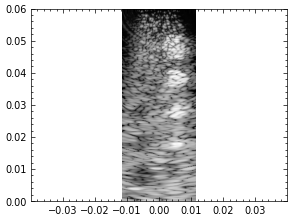

In [ ]:
#import cvxpy as cp
from scipy.sparse import lil_matrix, csr_matrix
from scipy.signal import gausspulse

plt.rcParams['text.usetex'] = False

MC_ITERATIONS = 40
MC_NUM_POINTS = 10

cscmux_monte_carlo_config = {
    'cvar': np.array([0.0, 0.05, 0.1]),#np.linspace(0.0, 0.1, MC_NUM_POINTS),
    'jitter_factor': np.array([0.0, 0.1, 0.2]),#np.linspace(0.0, 0.1, MC_NUM_POINTS),
    'charge_injection_factor': np.array([0.0, 0.1, 0.2]),#np.linspace(0.0, 0.2, MC_NUM_POINTS)
    'clock_feedthrough_factor': np.array([0.0, 0.1, 0.2])#np.linspace(0.0, 0.1, MC_NUM_POINTS),
    #'gain_error_factor': np.linspace(0.1, 10.0, MC_NUM_POINTS)
}

RUN_CHARGE_SHARING_CMUX_EVALUATION_ROUTINE = True

fs_settings = [50e6] # 50 MHz
f0_settings = [2.5e6] # 2.5 MHz

current_iteration = 1

if RUN_CHARGE_SHARING_CMUX_EVALUATION_ROUTINE:
  for fsidx, f0_setting in enumerate(f0_settings):
      current_iteration = 1
      # Build simulation media
      # Setup 2D array parameters:
      param = pymust.utils.Param()
      param.fc = f0_setting
      wavelength = c0 / f0_setting
      pitch = wavelength / 2
      param.kerf = KERF
      param.pitch = pitch
      param.width = pitch - param.kerf
      param.height = ROWS * pitch - param.kerf
      param.Nelements = COLUMNS
      param.bandwidth = 70
      param.radius = np.inf
      param.fs = fs_settings[fsidx]
      param.attenuation = 0.5
      # Setup the simulation medium
      dx = dy = dz = wavelength / 10
      Nx = int(Dx / dx) + 1 # Azimutal dir.
      Nz = int(Dy / dy) + 1 # Longitudinal dir.
      Ny = int(Dz / dz) + 1 # Elevational dir.
      x_extent = np.linspace(-Dx/2,Dx/2,Nx)
      z_extent = np.linspace(0,Dz,Nz)
      xi,zi = np.meshgrid(x_extent, z_extent);
      yi = np.zeros(xi.shape)
      fc = 10 * param.fc # 10 * Center Frequency at least
      xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/param.fc)
      RC = 0.1 * RC
      # Setup scatterer and hole location
      # draw increasing hole scatterers
      startx = -MAX_DIAMETER
      centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
      startz = MAX_DIAMETER * 1.5
      centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
      diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)
      for k, cz in enumerate(centerz):
          RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[0], cz), np.min(RC))
      for k, cz in enumerate(centerz[::-1]):
          RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[1], cz), np.max(RC))
      # region without echoes / reflectionless (blood vessels)
      anechoic_roi = np.zeros(xi.shape)
      # region with maximal echo / reflection (bones, nerves)
      hyperechoic_roi = np.zeros(xi.shape)
      for k, cz in enumerate(centerz):
          mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
          anechoic_roi[mask] = 1
      for k, cz in enumerate(centerz[::-1]):
          mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
          hyperechoic_roi[mask] = 1
      # Setup transmit events
      MAX_ANGLE = 0 # 10.0
      MIN_ANGLE = 0 # -10.0
      NUM_PLANAR_WAVES = 1
      tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
      #tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
      width = 20/180*np.pi # Diverging wave width with 30 degrees
      txdel = []
      for t in tilt:
          txdel.append(pymust.txdelay(param, t, width))
      txdel_planar = np.array(txdel)
      # Re-simulate RF channels
      RF = [0]*len(txdel_planar)
      for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
        RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
        RF[k] = RF[k] / np.max(np.abs(RF[k]))

      afe_cfg = AFEConfig()
      afe = AFE(param, afe_cfg)

      RF_tgc = []
      for r in RF:
        #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
        RF_tgc.append(afe(r))

      IQ = []
      for r in RF_tgc:
          IQ.append(pymust.rf2iq(r,param.fs,param.fc))
      bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
      for k, t in enumerate(txdel_planar):
          param.TXdelay = t
          bIQ[:,:,k] = (pymust.dasmtx(IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
      cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
      I = pymust.bmode(cIQ,40); #log-compressed image
      Ifiltered = denoise_bilateral(I, sigma_color=0.08, sigma_spatial=10)

      img_evaluator = ImageMetricEvaluator(I, anechoic_roi, hyperechoic_roi)
      plt.imshow(Ifiltered, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
      plt.axis('equal')
      plt.savefig(savedir + 'diff_cs_cmux_reference.pdf', dpi=300)
      plt.show()

      fig, ax = plt.subplots(4,3,figsize=(6,9))
      # Precompute heavy matrices

      N, nchannels = RF_tgc[0].shape
      t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / param.fs
      t = t[:N]
      basis_function = gausspulse(t, fc=param.fc, bw=param.bandwidth/100, bwr=-6, tpr=-60)
      Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction
      for i in range(N):
          shifted = shift(basis_function, i - int(N/2), cval=0.0)
          nonzero_idx = shifted.nonzero()[0]
          Vpe[nonzero_idx, i] = shifted[nonzero_idx]
      Vpe = csr_matrix(Vpe)
      Vpe = Vpe.T

      P = LFSR(N, nchannels)(taps=(7,1), seed=1234)
      P = 2*P - 1
      P = P.T
      P = P[:N, :]
      batch_size = 10
      nbatches = int(nchannels / batch_size)
      PhiPsiList = []
      [PhiPsiList.append(csr_matrix(np.hstack([
        np.diag(P[:, batch*batch_size + j]) \
          @ Vpe for j in range(batch_size)
      ]))) for batch in range(nbatches)]

      for paridx, parameter in enumerate(cscmux_monte_carlo_config.keys()):
        cscmux_config = {
            'cvar': 0.0,
            'jitter_factor': 0.0,
            'charge_injection_factor': 0.0,
            'clock_feedthrough_factor': 0.0,
            'gain_error_factor': np.inf,
            'f0_mhz': f0_setting/1e6,
            'fs_mhz': fs_settings[fsidx]/1e6,
            'ch_compression': 10
        }
        for validx, val in enumerate(cscmux_monte_carlo_config[parameter]):
          vals = val + np.max(cscmux_monte_carlo_config[parameter]) * 0.1 * np.random.randn(MC_ITERATIONS)
          for iter in range(MC_ITERATIONS):
            cscmux_config[parameter] = vals[iter]
            cmux = ChargeSharingCMUXCompressor(fclk=fs_settings[fsidx], compression=cscmux_config['ch_compression'], zero_prob=0, seed=1234)
            X_hat = []
            for r in RF_tgc:
              t = np.arange(0, r.shape[0])/param.fs
              Y, _ = cmux.multiplex(r/np.max(np.abs(r)), t, P, **cscmux_config)
              X_hat.append(cmux.demultiplex(Y/np.max(np.abs(Y)), Vpe, PhiPsiList, fc=param.fc, bw=param.bandwidth/100, epsilon=1e-6)[0])

            IQ = []
            for r in X_hat:
                IQ.append(pymust.rf2iq(r,param.fs,param.fc))
            bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
            for k, t in enumerate(txdel_planar):
                param.TXdelay = t
                bIQ[:,:,k] = (pymust.dasmtx(IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
            cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
            Imeas = pymust.bmode(cIQ,40); #log-compressed image
            Imeasfiltered = denoise_bilateral(Imeas, sigma_color=0.08, sigma_spatial=10)

            ax[paridx,validx].imshow(Imeasfiltered, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
            #ax[paridx,validx].set_axis('equal')


            results_img_eval_raw = img_evaluator.evaluate(Imeas)
            results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
            results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
            results_img_eval.update(cscmux_config)
            print(results_img_eval)
            if current_iteration == 1:
                with open(dir + 'mc_results_matched_differential_cs_cmux_nonideal.csv', 'a') as fp:
                    fp.write(','.join([k for k in  results_img_eval.keys()])+'\n')
            #print(results_db_row)
            with open(dir + 'mc_results_matched_differential_cs_cmux_nonideal.csv', 'a') as fp:
                fp.write(','.join([str(k) for k in  results_img_eval.values()])+'\n')

            current_iteration += 1
#fig.tight_layout()
#fig.savefig(savedir + f'diff_cs_cmux_{parameter}_{validx}.pdf', dpi=300)

### Analyse results of Charge-Sharing CMUX vs. Boxcar Sampler Non-Idealities

In [ ]:
!pip install scienceplots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['science', 'nature'])

## Charge-Sharing CMUX Non-Idealities vs. Color Doppler US Imaging Quality

In [ ]:
class ImageMetricEvaluatorSimpler():
  golden_reference: np.ndarray = None
  anechoic_roi: np.ndarray = None
  hyperechoic_roi: np.ndarray = None
  def __init__(self, golden_reference):
    self.golden_reference = golden_reference
    self.golden_reference8b = (self.golden_reference * 255).astype(np.uint8)
    self.golden_reference8b = self.golden_reference8b.astype(np.float64)

  def _mse(self, I):
    I8b = (I * 255).astype(np.uint8)
    I8b = I8b.astype(np.float64)
    return np.mean((self.golden_reference8b - I8b)**2)

  def _psnr(self, I):
    mse = self._mse(I)
    return 20 * np.log10( 255 / np.sqrt(mse))

  def _ssim(self, I):
    from skimage.metrics import structural_similarity as ssim
    return ssim(self.golden_reference, I, data_range=self.golden_reference.max() - self.golden_reference.min())


  def evaluate(self, I):
    return {
        "mse": self._mse(I),
        "psnr": self._psnr(I),
        "ssim": self._ssim(I),
    }

In [ ]:
#import cvxpy as cp
from scipy.sparse import lil_matrix, csr_matrix
from scipy.signal import gausspulse
import os

plt.rcParams['text.usetex'] = False

MC_ITERATIONS = 40
MC_NUM_POINTS = 10

cscmux_monte_carlo_config = {
    'cvar': np.linspace(0.0, 0.1, MC_NUM_POINTS),
    'jitter_factor': np.linspace(0.0, 0.2, MC_NUM_POINTS),
    'charge_injection_factor': np.linspace(0.0, 0.2, MC_NUM_POINTS),
    'clock_feedthrough_factor': np.linspace(0.0, 0.2, MC_NUM_POINTS),
    'gain_error_factor': np.linspace(0.1, 10.0, MC_NUM_POINTS)
}

RUN_CHARGE_SHARING_CMUX_COLOR_DOPPLER_EVALUATION_ROUTINE = True

fs_settings = [50e6] # 50 MHz
f0_settings = [2.5e6] # 2.5 MHz

class MyOptions(pymust.utils.Options):
    def copy(self):
        p = MyOptions()
        for k in self.keys():
            p[k] = self[k]
        return p

def rotatePoints(x, y, x0, y0, theta):
    """
    Rotate points (x,y) around (x0,y0) by theta radians
    """
    x = x - x0
    y = y - y0
    x1 = x * np.cos(theta) - y * np.sin(theta) + x0
    y1 = x * np.sin(theta) + y * np.cos(theta) + y0
    return x1, y1


current_iteration = 1

if RUN_CHARGE_SHARING_CMUX_COLOR_DOPPLER_EVALUATION_ROUTINE:
  for fsidx, f0_setting in enumerate(f0_settings):
      current_iteration = 1

      options =  MyOptions()
      options.ParPoolMode = 'thread'
      options.ParPool_NumWorkers = 12
      options.dBThresh = -6
      options.ParPool = os.name == 'posix'
      c0 = 1540 # m/s
      wavelength = c0 / f0_setting
      pitch = wavelength / 2
      max_pitch = 385e-6 # pitch of 2MHz array
      COLUMNS = 40
      ROWS = 40
      kerf = 25e-6
      APERTURE_X = COLUMNS * max_pitch - kerf
      APERTURE_Y = ROWS * max_pitch - kerf
      depth = 5e-2
      # Setup 2D array
      param = pymust.utils.Param()
      param.fc = f0_setting
      wavelength = c0 / f0_setting
      pitch = wavelength / 2
      param.kerf = 25e-06 # 50 um kerf
      param.pitch = pitch
      param.width = pitch - param.kerf
      param.height = APERTURE_Y - param.kerf
      param.Nelements = COLUMNS
      #BW = 300.0e3
      #param.bandwidth = 100*(BW/ param.fc) # percentage
      param.bandwidth = 70
      param.radius = np.inf
      param.fs = fs_settings[fsidx]
      param.attenuation = 0.5

      IQ = None
      RFs = None
      RFs_tgc = None

      small_test = True # Turn it to true if your computer has problems computing
      #param = pymust.getparam('L11-5v')
      param.TXnow = 10
      nPoints = 500000 if not small_test else 50000
      xs = np.random.rand(1,nPoints)*APERTURE_X - APERTURE_X / 2
      zs = np.random.rand(1,nPoints)*APERTURE_X
      centerDisk = APERTURE_X / 2
      idx = np.hypot(xs,zs-centerDisk)<3e-3 # First disk
      #idx2 = np.hypot(xs,zs-.035)< 5e-3 # Second disk, smaller with high intensity
      RC = np.random.rand(*xs.shape)  # reflection coefficients
      # Add reflectiion to both spheres
      RC[idx] += .5
      # Rotating disk velocity
      rotation_frequency = 50 # Hz
      w = 2 * np.pi  * rotation_frequency#1 Hz = 2 pi rads
      nreps = 5
      PRF = 10e3 # at least 200 Hz, for nyquist sampling of rotation
      param.PRP = 1 / PRF
      width = 10/180*np.pi; # width angle in rad
      txdel = pymust.txdelay(param,0,width) # in s
      RFs = None
      RFs_tgc = None
      IQ = None
      for i in tqdm.tqdm(range(nreps)):
          xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  w * param.PRP)
          #txdel =pymust.txdelayPlane(param, 0)
          RF, _ = pymust.simus(xs,zs,RC,txdel,param, options)
          if i ==0:
              IQ = np.zeros([RF.shape[0], RF.shape[1], nreps], dtype = np.complex128)
              RFs = np.zeros([RF.shape[0], RF.shape[1], nreps])
              RFs_tgc = np.zeros([RF.shape[0], RF.shape[1], nreps])
          RFs[:, :, i] = RF
          RFs_tgc[:, :, i], _ = pymust.tgc(RF)
          IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i], param)
      # Num points
      dx = dz = wavelength / 10
      Nx = int(APERTURE_X / dx)
      Nz = int(APERTURE_X / dz)
      x_extent = np.linspace(-APERTURE_X/2, APERTURE_X/2, Nx)
      z_extent = np.linspace(0, APERTURE_X, Nz)
      xi,zi = np.meshgrid(x_extent, z_extent)
      #x,z = pymust.impolgrid(np.array([Nx, Nz], dtype = np.int64),APERTURE_X, np.pi/2, param)
      Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
      IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
      bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)
      for i in tqdm.tqdm(range(nreps)):
          IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
          bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])

      doppler_vel, doppler_var = pymust.iq2doppler(IQb,param)
      VN = pymust.getNyquistVelocity(param)

      img_evaluator = ImageMetricEvaluatorSimpler(doppler_vel)
      plt.imshow(doppler_vel, cmap = 'bwr')
      #plt.axis('equal')
      #plt.savefig(dir+'cmux_eval_result_comp_ch_{comp_ch}_fclk_{fclk}.pdf', dpi=300)
      plt.show()


      # Precompute heavy matrices

      N, nchannels = RFs_tgc.shape[0], RFs_tgc.shape[1]
      t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / param.fs
      t = t[:N]
      basis_function = gausspulse(t, fc=param.fc, bw=param.bandwidth/100, bwr=-6, tpr=-60)
      Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction
      for i in range(N):
          shifted = shift(basis_function, i - int(N/2), cval=0.0)
          nonzero_idx = shifted.nonzero()[0]
          Vpe[nonzero_idx, i] = shifted[nonzero_idx]
      Vpe = csr_matrix(Vpe)
      Vpe = Vpe.T

      P = LFSR(N, nchannels)(taps=(7,1), seed=1234)
      P = 2*P - 1
      P = P.T
      P = P[:N, :]
      batch_size = 10
      nbatches = int(nchannels / batch_size)
      PhiPsiList = []
      [PhiPsiList.append(csr_matrix(np.hstack([
        np.diag(P[:, batch*batch_size + j]) \
          @ Vpe for j in range(batch_size)
      ]))) for batch in range(nbatches)]

      tt = np.arange(0, N)/param.fs

      for parameter in cscmux_monte_carlo_config.keys():
        cscmux_config = {
            'cvar': 0.0,
            'jitter_factor': 0.0,
            'charge_injection_factor': 0.0,
            'clock_feedthrough_factor': 0.0,
            'gain_error_factor': np.inf,
            'f0_mhz': f0_setting/1e6,
            'fs_mhz': fs_settings[fsidx]/1e6,
            'ch_compression': 10
        }
        for validx, val in enumerate(cscmux_monte_carlo_config[parameter]):
          vals = val + np.max(cscmux_monte_carlo_config[parameter]) * 0.1 * np.random.randn(MC_ITERATIONS)
          for iter in range(MC_ITERATIONS):
            cscmux_config[parameter] = vals[iter]
            cmux = ChargeSharingCMUXCompressor(fclk=fs_settings[fsidx], compression=cscmux_config['ch_compression'], zero_prob=0, seed=1234)

            X_hat = np.zeros_like(RFs)
            for i in tqdm.tqdm(range(nreps)):
              Y, _ = cmux.multiplex(RFs_tgc[:, :, i]/np.max(np.abs(RFs_tgc[:, :, i])), tt, P, **cscmux_config)
              X_hat[:,:, i] = cmux.demultiplex(Y/np.max(np.abs(Y)), Vpe, PhiPsiList, fc=param.fc, bw=param.bandwidth/100, epsilon=1e-6)[0]

            IQ = None
            for i in tqdm.tqdm(range(nreps)):
                xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  w * param.PRP)
                #txdel =pymust.txdelayPlane(param, 0)
                #RF, _ = pymust.simus(xs,zs,RC,txdel,param, options)
                if i ==0:
                    IQ = np.zeros([RF.shape[0], RF.shape[1], nreps], dtype = np.complex128)
                IQ[:, :, i] = pymust.rf2iq(X_hat[:, :, i], param)

            Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
            IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
            bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)
            for i in tqdm.tqdm(range(nreps)):
                IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
                bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])

            doppler_vel_meas, doppler_var_meas = pymust.iq2doppler(IQb,param)

            results_img_eval_raw = img_evaluator.evaluate(doppler_vel_meas)
            results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
            #results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
            results_img_eval.update(cscmux_config)
            print(results_img_eval)
            if current_iteration == 1:
                with open(dir + 'mc_results_matched_differential_cs_cmux_nonideal_color_doppler.csv', 'a') as fp:
                    fp.write(','.join([k for k in  results_img_eval.keys()])+'\n')
            #print(results_db_row)
            with open(dir + 'mc_results_matched_differential_cs_cmux_nonideal_color_doppler.csv', 'a') as fp:
                fp.write(','.join([str(k) for k in  results_img_eval.values()])+'\n')

            current_iteration += 1
